# Final K-Means Customer Segmentation — K = 5



## Phase 1: Setup and input validation

This phase prepares the notebook and checks that both customer datasets are suitable for modelling.


###  1: Import the required libraries




In [1]:
import os
import sys
import json
import shutil
import platform
import warnings
import joblib
from pathlib import Path
from importlib import metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_style("whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


###  2: Define the input and output paths



In [2]:
processed_file = "/content/customer_features_processed.csv"

raw_file_candidates = [
    "/content/customer_features_ready_for_preprocessing.csv",
    "/content/customer_features_raw.csv"
]

raw_file = next(
    (path for path in raw_file_candidates if os.path.exists(path)),
    raw_file_candidates[0]
)

results_dir = Path("/content/Final_KMeans_K5_Updated_Results")
tables_dir = results_dir / "Tables"
figures_dir = results_dir / "Figures"
models_dir = results_dir / "Models"
datasets_dir = results_dir / "Datasets"
stability_dir = results_dir / "Stability"
reproducibility_dir = results_dir / "Reproducibility"

for folder in [
    results_dir,
    tables_dir,
    figures_dir,
    models_dir,
    datasets_dir,
    stability_dir,
    reproducibility_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Processed file:", processed_file)
print("Original-scale file:", raw_file)
print("Output folder:", results_dir)


Processed file: /content/customer_features_processed.csv
Original-scale file: /content/customer_features_ready_for_preprocessing.csv
Output folder: /content/Final_KMeans_K5_Updated_Results


###  3: Load the two customer datasets

In [3]:
if not os.path.exists(processed_file):
    raise FileNotFoundError(
        f"Processed dataset not found: {processed_file}"
    )

if not os.path.exists(raw_file):
    raise FileNotFoundError(
        "Original-scale customer feature dataset was not found. "
        "Upload customer_features_ready_for_preprocessing.csv."
    )

processed_data = pd.read_csv(processed_file)
raw_data = pd.read_csv(raw_file)

print("=" * 80)
print("DATASETS LOADED")
print("=" * 80)

print("\nProcessed dataset shape:", processed_data.shape)
print("Original-scale dataset shape:", raw_data.shape)

print("\nProcessed dataset preview:")
display(processed_data.head())

print("\nOriginal-scale dataset preview:")
display(raw_data.head())


DATASETS LOADED

Processed dataset shape: (4338, 8)
Original-scale dataset shape: (4338, 9)

Processed dataset preview:


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561



Original-scale dataset preview:


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,"77,183.6000",74215,1,1,"77,183.6000","74,215.0000"
1,12347,2,7,"4,310.0000",2458,103,182,615.7100,351.1400
2,12348,75,4,"1,797.2400",2341,22,31,449.3100,585.2500
3,12349,19,1,"1,757.5500",631,73,73,"1,757.5500",631.0000
4,12350,310,1,334.4000,197,17,17,334.4000,197.0000


###  4: Validate columns, missing values and customer IDs


In [4]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

required_columns = ["CustomerID"] + feature_columns

missing_processed = [
    column for column in required_columns
    if column not in processed_data.columns
]

missing_raw = [
    column for column in required_columns
    if column not in raw_data.columns
]

if missing_processed:
    raise ValueError(
        f"Missing columns in processed dataset: {missing_processed}"
    )

if missing_raw:
    raise ValueError(
        f"Missing columns in original-scale dataset: {missing_raw}"
    )

if processed_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values found in processed dataset."
    )

if raw_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values found in original-scale dataset."
    )

if processed_data[required_columns].isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in processed clustering dataset."
    )

if raw_data[required_columns].isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in original-scale dataset."
    )

print("Required columns and customer IDs validated successfully.")


Required columns and customer IDs validated successfully.


###  5: Align the datasets and create the feature matrix


In [5]:
raw_data = (
    processed_data[["CustomerID"]]
    .merge(
        raw_data[required_columns],
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

if raw_data.isnull().sum().sum() > 0:
    raise ValueError(
        "CustomerID alignment failed between the two datasets."
    )

if not np.array_equal(
    processed_data["CustomerID"].to_numpy(),
    raw_data["CustomerID"].to_numpy()
):
    raise ValueError(
        "Customer ordering is not aligned between the datasets."
    )

X = processed_data[feature_columns].copy()

if not np.isfinite(X.to_numpy()).all():
    raise ValueError(
        "Infinite or non-finite values found in clustering features."
    )

print("=" * 80)
print("INPUT VALIDATION COMPLETED")
print("=" * 80)

print("\nCustomers:", len(X))
print("Features:", len(feature_columns))
print("\nFeatures used:")
print(feature_columns)

display(X.describe().T)


INPUT VALIDATION COMPLETED

Customers: 4338
Features: 7

Features used:
['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.0000",0.3350,0.8066,-0.4032,-0.2661,0.0000,0.7339,2.6048
Frequency,"4,338.0000",0.2248,0.6218,-0.3691,-0.3691,0.0000,0.6309,3.8671
Monetary,"4,338.0000",0.0486,0.7459,-2.9331,-0.4613,-0.0000,0.5387,3.5781
AverageOrderValue,"4,338.0000",-0.0388,0.8516,-4.7825,-0.5635,0.0000,0.4365,6.4666
BasketSize,"4,338.0000",-0.0439,0.8450,-4.1088,-0.5189,0.0000,0.4811,5.7289
ProductDiversity,"4,338.0000",-0.0210,0.7427,-1.8972,-0.4925,0.0000,0.5075,2.5634
TotalQuantity,"4,338.0000",0.0239,0.7517,-2.8763,-0.4730,0.0000,0.5270,3.4295


## Phase 2: Model training and internal validation

The final K=5 model is fitted and its compactness, separation and cluster sizes are examined.


###  6: Train the final K=5 model

K-Means is fitted using K-Means++ initialisation, 50 initialisations, 500 maximum iterations and a fixed random state. Labels are added to both datasets and the model is saved.


In [6]:
FINAL_K = 5
RANDOM_STATE = 42
N_INIT = 50
MAX_ITER = 500

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="lloyd"
)

final_labels = final_kmeans.fit_predict(X)

processed_clustered = processed_data.copy()
processed_clustered["Cluster"] = final_labels

raw_clustered = raw_data.copy()
raw_clustered["Cluster"] = final_labels

joblib.dump(
    final_kmeans,
    models_dir / "final_kmeans_k5_model.joblib"
)

with open(
    models_dir / "final_feature_columns.json",
    "w"
) as file:
    json.dump(feature_columns, file, indent=4)

print("=" * 80)
print("FINAL K-MEANS MODEL TRAINED")
print("=" * 80)

print("Selected K:", FINAL_K)
print("Iterations to converge:", final_kmeans.n_iter_)
print("Cluster labels:", sorted(np.unique(final_labels)))


FINAL K-MEANS MODEL TRAINED
Selected K: 5
Iterations to converge: 37
Cluster labels: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


###  7: Reload and verify the saved model




In [7]:
# VERIFY THE SAVED K-MEANS MODEL

saved_model_path = (
    models_dir / "final_kmeans_k5_model.joblib"
)

reloaded_kmeans = joblib.load(
    saved_model_path
)

reloaded_labels = reloaded_kmeans.predict(X)

if not np.array_equal(
    final_labels,
    reloaded_labels
):
    raise AssertionError(
        "The reloaded K-Means model did not reproduce "
        "the original cluster assignments."
    )

print(
    "Saved model verification passed: "
    "all cluster assignments were reproduced."
)


Saved model verification passed: all cluster assignments were reproduced.


###  8: Calculate the final validation metrics
Inertia, Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz Index are calculated and saved.



In [8]:
final_silhouette = silhouette_score(X, final_labels)
final_dbi = davies_bouldin_score(X, final_labels)
final_ch = calinski_harabasz_score(X, final_labels)
final_inertia = final_kmeans.inertia_

final_validation = pd.DataFrame({
    "Metric": [
        "Selected K",
        "WCSS / Inertia",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Iterations to Converge"
    ],
    "Value": [
        FINAL_K,
        final_inertia,
        final_silhouette,
        final_dbi,
        final_ch,
        final_kmeans.n_iter_
    ]
})

print("=" * 80)
print("FINAL INTERNAL VALIDATION")
print("=" * 80)

display(final_validation)

final_validation.to_csv(
    tables_dir / "final_kmeans_validation_metrics.csv",
    index=False
)


FINAL INTERNAL VALIDATION


,Metric,Value
0,Selected K,5.0000
1,WCSS / Inertia,"6,866.0351"
2,Silhouette Score,0.2512
3,Davies-Bouldin Index,1.2230
4,Calinski-Harabasz Index,"1,755.9685"
5,Iterations to Converge,37.0000


###  9: Calculate customer count in each cluster



In [9]:
cluster_size = (
    raw_clustered["Cluster"]
    .value_counts()
    .sort_index()
    .reindex(range(FINAL_K), fill_value=0)
    .rename_axis("Cluster")
    .reset_index(name="Customer_Count")
)

cluster_size["Customer_Percentage"] = (
    cluster_size["Customer_Count"]
    / len(raw_clustered)
    * 100
).round(2)

cluster_size["Is_Smaller_Than_5_Percent"] = (
    cluster_size["Customer_Percentage"] < 5
)

print("=" * 80)
print("FINAL CLUSTER SIZE ANALYSIS")
print("=" * 80)

display(cluster_size)

cluster_size.to_csv(
    tables_dir / "final_cluster_size_analysis.csv",
    index=False
)


FINAL CLUSTER SIZE ANALYSIS


,Cluster,Customer_Count,Customer_Percentage,Is_Smaller_Than_5_Percent
0,0,661,15.2400,False
1,1,1454,33.5200,False
2,2,993,22.8900,False
3,3,520,11.9900,False
4,4,710,16.3700,False


### Block 10: Plot the cluster sizes




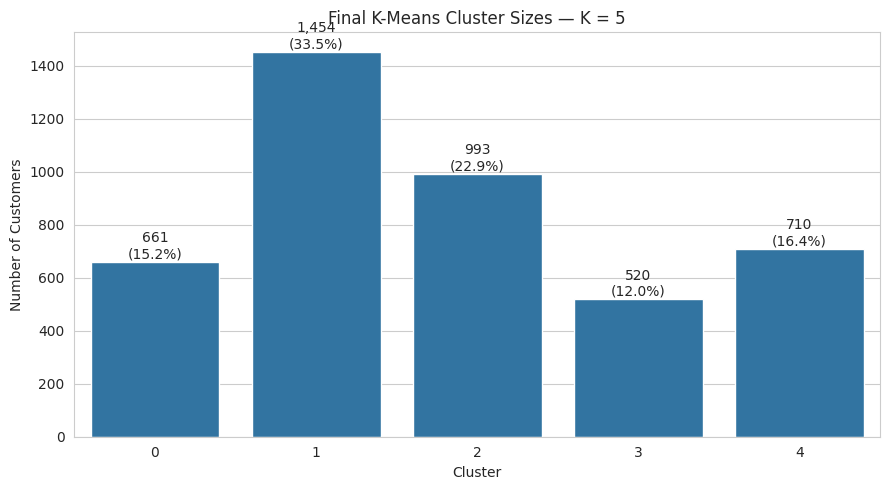

In [10]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=cluster_size,
    x="Cluster",
    y="Customer_Count"
)

for index, row in cluster_size.iterrows():
    ax.text(
        index,
        row["Customer_Count"],
        (
            f'{row["Customer_Count"]:,}\n'
            f'({row["Customer_Percentage"]:.1f}%)'
        ),
        ha="center",
        va="bottom"
    )

plt.title("Final K-Means Cluster Sizes — K = 5")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    figures_dir / "final_cluster_sizes_by_number.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  11: Calculate customer and cluster silhouette values



In [11]:
customer_silhouette = silhouette_samples(X, final_labels)

processed_clustered["Silhouette_Value"] = customer_silhouette
raw_clustered["Silhouette_Value"] = customer_silhouette

silhouette_summary = (
    raw_clustered
    .groupby("Cluster")["Silhouette_Value"]
    .agg(
        Customer_Count="count",
        Mean_Silhouette="mean",
        Median_Silhouette="median",
        Minimum_Silhouette="min",
        Maximum_Silhouette="max",
        Standard_Deviation="std"
    )
    .reset_index()
)

negative_counts = (
    raw_clustered
    .assign(Is_Negative=raw_clustered["Silhouette_Value"] < 0)
    .groupby("Cluster")["Is_Negative"]
    .sum()
    .reset_index(name="Negative_Silhouette_Customers")
)

silhouette_summary = silhouette_summary.merge(
    negative_counts,
    on="Cluster",
    how="left"
)

silhouette_summary["Negative_Silhouette_Percentage"] = (
    silhouette_summary["Negative_Silhouette_Customers"]
    / silhouette_summary["Customer_Count"]
    * 100
).round(2)

silhouette_summary = silhouette_summary.round(4)

overall_negative_count = int(
    (customer_silhouette < 0).sum()
)

overall_negative_percentage = (
    overall_negative_count
    / len(customer_silhouette)
    * 100
)

overall_silhouette_summary = pd.DataFrame({
    "Measure": [
        "Overall Silhouette Score",
        "Ambiguous / Boundary Customers",
        "Ambiguous / Boundary Customer Percentage"
    ],
    "Value": [
        final_silhouette,
        overall_negative_count,
        overall_negative_percentage
    ]
})

print("=" * 80)
print("SILHOUETTE QUALITY BY CLUSTER")
print("=" * 80)

display(silhouette_summary)

print("\nOverall silhouette summary:")
display(overall_silhouette_summary)

silhouette_summary.to_csv(
    tables_dir / "final_cluster_silhouette_summary.csv",
    index=False
)

overall_silhouette_summary.to_csv(
    tables_dir / "overall_silhouette_summary.csv",
    index=False
)


SILHOUETTE QUALITY BY CLUSTER


,Cluster,Customer_Count,Mean_Silhouette,Median_Silhouette,Minimum_Silhouette,Maximum_Silhouette,Standard_Deviation,Negative_Silhouette_Customers,Negative_Silhouette_Percentage
0,0,661,0.2991,0.3149,-0.0219,0.5380,0.1461,5,0.7600
1,1,1454,0.2822,0.2898,0.0106,0.5343,0.1281,0,0.0000
2,2,993,0.2828,0.2951,-0.0122,0.5223,0.1448,13,1.3100
3,3,520,0.1726,0.1729,-0.1356,0.4416,0.1472,83,15.9600
4,4,710,0.1566,0.1456,-0.0617,0.4279,0.1305,104,14.6500



Overall silhouette summary:


,Measure,Value
0,Overall Silhouette Score,0.2512
1,Ambiguous / Boundary Customers,205.0000
2,Ambiguous / Boundary Customer Percentage,4.7257


###  12: Plot the silhouette distribution



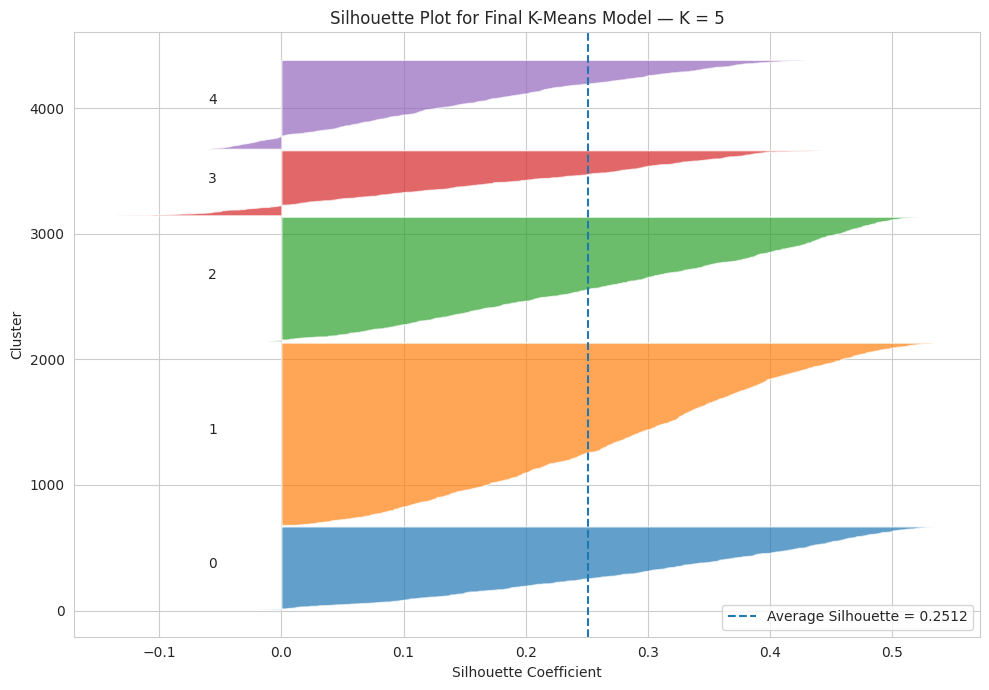

In [12]:
plt.figure(figsize=(10, 7))

y_lower = 10

for cluster_number in range(FINAL_K):
    cluster_values = customer_silhouette[
        final_labels == cluster_number
    ]

    cluster_values.sort()

    cluster_count = cluster_values.shape[0]
    y_upper = y_lower + cluster_count

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        alpha=0.70
    )

    plt.text(
        -0.06,
        y_lower + 0.5 * cluster_count,
        str(cluster_number)
    )

    y_lower = y_upper + 10

plt.axvline(
    final_silhouette,
    linestyle="--",
    label=f"Average Silhouette = {final_silhouette:.4f}"
)

plt.title("Silhouette Plot for Final K-Means Model — K = 5")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "final_silhouette_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Phase 3: Cluster profiling and business interpretation

The original customer values are used to understand, name and compare the five groups.


###  13: Create mean and median cluster profiles


In [13]:
cluster_profile_mean = (
    raw_clustered
    .groupby("Cluster")[feature_columns]
    .mean()
    .round(2)
)

cluster_profile_median = (
    raw_clustered
    .groupby("Cluster")[feature_columns]
    .median()
    .round(2)
)

cluster_profile_mean["Customer_Count"] = (
    raw_clustered.groupby("Cluster").size()
)

cluster_profile_mean["Customer_Percentage"] = (
    cluster_profile_mean["Customer_Count"]
    / len(raw_clustered)
    * 100
).round(2)

cluster_profile_median["Customer_Count"] = (
    raw_clustered.groupby("Cluster").size()
)

cluster_profile_median["Customer_Percentage"] = (
    cluster_profile_median["Customer_Count"]
    / len(raw_clustered)
    * 100
).round(2)

print("=" * 80)
print("ORIGINAL-SCALE MEAN PROFILES")
print("=" * 80)
display(cluster_profile_mean)

print("\nOriginal-scale median profiles:")
display(cluster_profile_median)

cluster_profile_mean.to_csv(
    tables_dir / "final_cluster_profiles_mean.csv"
)

cluster_profile_median.to_csv(
    tables_dir / "final_cluster_profiles_median.csv"
)


ORIGINAL-SCALE MEAN PROFILES


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,Customer_Count,Customer_Percentage
Cluster,,,,,,,,,
0,260.6700,1.4100,362.0600,276.1700,148.8800,21.3400,190.5900,661,15.2400
1,47.6000,2.8000,622.1400,243.5200,142.7300,42.1100,351.6200,1454,33.5200
2,23.8400,11.3000,"6,236.2200",475.0500,280.9100,147.3100,"3,590.2900",993,22.8900
3,138.1000,1.5400,165.0800,114.4900,44.9400,9.2700,63.8500,520,11.9900
4,90.7500,2.1300,"2,063.2300","1,047.6800",685.8200,56.8400,"1,290.7200",710,16.3700



Original-scale median profiles:


,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,Customer_Count,Customer_Percentage
Cluster,,,,,,,,,
0,262.0000,1.0000,311.5500,251.8000,128.0000,17.0000,156.0000,661,15.2400
1,35.0000,2.0000,550.5500,228.0500,131.9200,33.0000,294.0000,1454,33.5200
2,15.0000,8.0000,"2,888.5500",376.0700,231.7500,113.0000,"1,747.0000",993,22.8900
3,113.0000,1.0000,128.5600,106.3800,41.0000,7.0000,54.5000,520,11.9900
4,71.0000,2.0000,"1,160.7800",600.0800,382.0000,46.0000,743.5000,710,16.3700


###  14: Compare mean and median Monetary values



In [14]:
mean_median_comparison = pd.DataFrame({
    "Cluster": cluster_profile_mean.index,
    "Mean_Monetary": cluster_profile_mean["Monetary"].values,
    "Median_Monetary": cluster_profile_median["Monetary"].values
})

mean_median_comparison["Mean_to_Median_Ratio"] = (
    mean_median_comparison["Mean_Monetary"]
    / mean_median_comparison["Median_Monetary"].replace(0, np.nan)
)

mean_median_comparison["Absolute_Difference"] = (
    mean_median_comparison["Mean_Monetary"]
    - mean_median_comparison["Median_Monetary"]
)

mean_median_comparison = mean_median_comparison.round(2)

display(mean_median_comparison)

mean_median_comparison.to_csv(
    tables_dir / "mean_vs_median_monetary_comparison.csv",
    index=False
)


,Cluster,Mean_Monetary,Median_Monetary,Mean_to_Median_Ratio,Absolute_Difference
0,0,362.0600,311.5500,1.1600,50.5100
1,1,622.1400,550.5500,1.1300,71.5900
2,2,"6,236.2200","2,888.5500",2.1600,"3,347.6700"
3,3,165.0800,128.5600,1.2800,36.5200
4,4,"2,063.2300","1,160.7800",1.7800,902.4500


###  15: Create relative cluster profile scores



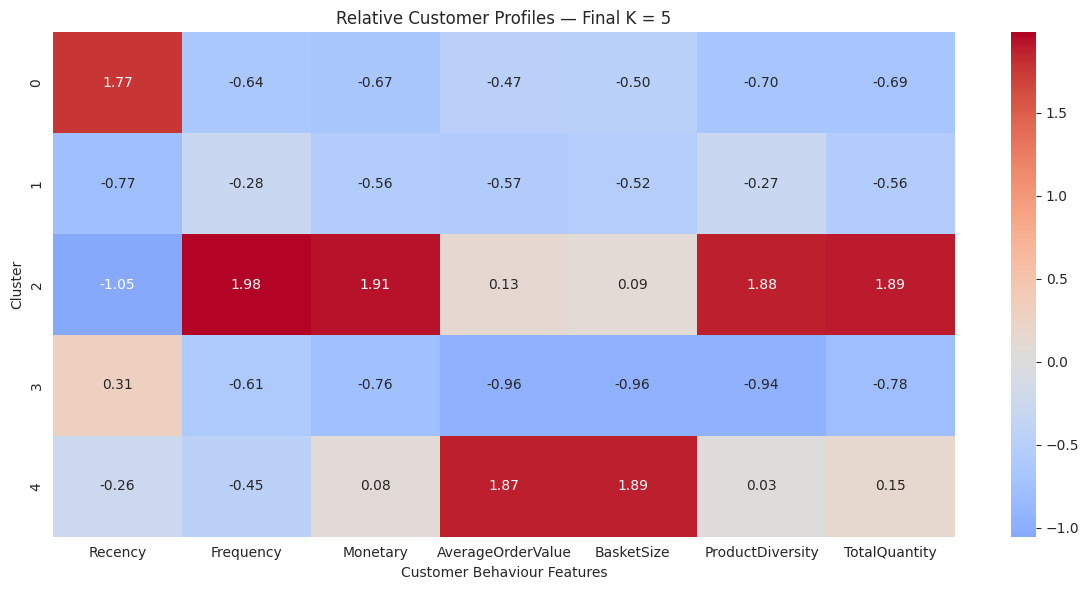

In [15]:
profile_values = cluster_profile_mean[feature_columns].copy()

relative_profiles = (
    profile_values - profile_values.mean()
) / profile_values.std(ddof=0).replace(0, 1)

relative_profiles = relative_profiles.round(3)

relative_profiles.to_csv(
    tables_dir / "final_cluster_relative_profile_scores.csv"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    relative_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Relative Customer Profiles — Final K = 5")
plt.xlabel("Customer Behaviour Features")
plt.ylabel("Cluster")
plt.tight_layout()

plt.savefig(
    figures_dir / "final_relative_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  16: Derive the five business segment names




In [16]:
profile_for_naming = cluster_profile_mean[feature_columns].copy()

remaining_clusters = set(profile_for_naming.index)
segment_mapping = {}

# Most dormant group: highest average Recency
dormant_cluster = profile_for_naming.loc[
    list(remaining_clusters),
    "Recency"
].idxmax()

segment_mapping[int(dormant_cluster)] = (
    "Dormant Occasional Customers"
)

remaining_clusters.remove(dormant_cluster)

# Most loyal group: highest Frequency
loyal_cluster = profile_for_naming.loc[
    list(remaining_clusters),
    "Frequency"
].idxmax()

segment_mapping[int(loyal_cluster)] = (
    "High-Value Loyal Customers"
)

remaining_clusters.remove(loyal_cluster)

# Large-order group: highest Average Order Value
large_order_cluster = profile_for_naming.loc[
    list(remaining_clusters),
    "AverageOrderValue"
].idxmax()

segment_mapping[int(large_order_cluster)] = (
    "High-Value Large-Order Buyers"
)

remaining_clusters.remove(large_order_cluster)

# Lowest-value group: lowest Monetary value
low_value_cluster = profile_for_naming.loc[
    list(remaining_clusters),
    "Monetary"
].idxmin()

segment_mapping[int(low_value_cluster)] = (
    "Low-Value Infrequent Customers"
)

remaining_clusters.remove(low_value_cluster)

# Remaining middle-value group
regular_cluster = list(remaining_clusters)[0]

segment_mapping[int(regular_cluster)] = (
    "Active Regular Customers"
)

segment_mapping_table = pd.DataFrame({
    "Cluster": sorted(segment_mapping),
    "Segment_Name": [
        segment_mapping[cluster]
        for cluster in sorted(segment_mapping)
    ]
})

if segment_mapping_table["Segment_Name"].nunique() != FINAL_K:
    raise ValueError(
        "Segment naming did not produce five unique business names."
    )

print("=" * 80)
print("FINAL BUSINESS SEGMENT MAPPING")
print("=" * 80)

display(segment_mapping_table)

segment_mapping_table.to_csv(
    tables_dir / "final_segment_mapping.csv",
    index=False
)


FINAL BUSINESS SEGMENT MAPPING


,Cluster,Segment_Name
0,0,Dormant Occasional Customers
1,1,Active Regular Customers
2,2,High-Value Loyal Customers
3,3,Low-Value Infrequent Customers
4,4,High-Value Large-Order Buyers


###  17: Apply the business names to the result tables

 The same business label must be attached consistently to every customer and summary table.So,the segment mapping is applied to the processed data, original-scale data, cluster-size table, silhouette table and profile tables.



In [17]:
processed_clustered["Segment_Name"] = (
    processed_clustered["Cluster"].map(segment_mapping)
)

raw_clustered["Segment_Name"] = (
    raw_clustered["Cluster"].map(segment_mapping)
)

cluster_size["Segment_Name"] = (
    cluster_size["Cluster"].map(segment_mapping)
)

silhouette_summary["Segment_Name"] = (
    silhouette_summary["Cluster"].map(segment_mapping)
)

cluster_profile_mean_named = (
    cluster_profile_mean.reset_index()
)

cluster_profile_mean_named["Segment_Name"] = (
    cluster_profile_mean_named["Cluster"].map(segment_mapping)
)

cluster_profile_median_named = (
    cluster_profile_median.reset_index()
)

cluster_profile_median_named["Segment_Name"] = (
    cluster_profile_median_named["Cluster"].map(segment_mapping)
)

display(
    cluster_profile_mean_named[
        [
            "Cluster",
            "Segment_Name",
            *feature_columns,
            "Customer_Count",
            "Customer_Percentage"
        ]
    ]
)


,Cluster,Segment_Name,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,Customer_Count,Customer_Percentage
0,0,Dormant Occasional Customers,260.6700,1.4100,362.0600,276.1700,148.8800,21.3400,190.5900,661,15.2400
1,1,Active Regular Customers,47.6000,2.8000,622.1400,243.5200,142.7300,42.1100,351.6200,1454,33.5200
2,2,High-Value Loyal Customers,23.8400,11.3000,"6,236.2200",475.0500,280.9100,147.3100,"3,590.2900",993,22.8900
3,3,Low-Value Infrequent Customers,138.1000,1.5400,165.0800,114.4900,44.9400,9.2700,63.8500,520,11.9900
4,4,High-Value Large-Order Buyers,90.7500,2.1300,"2,063.2300","1,047.6800",685.8200,56.8400,"1,290.7200",710,16.3700


###  18: Plot customer distribution by segment name




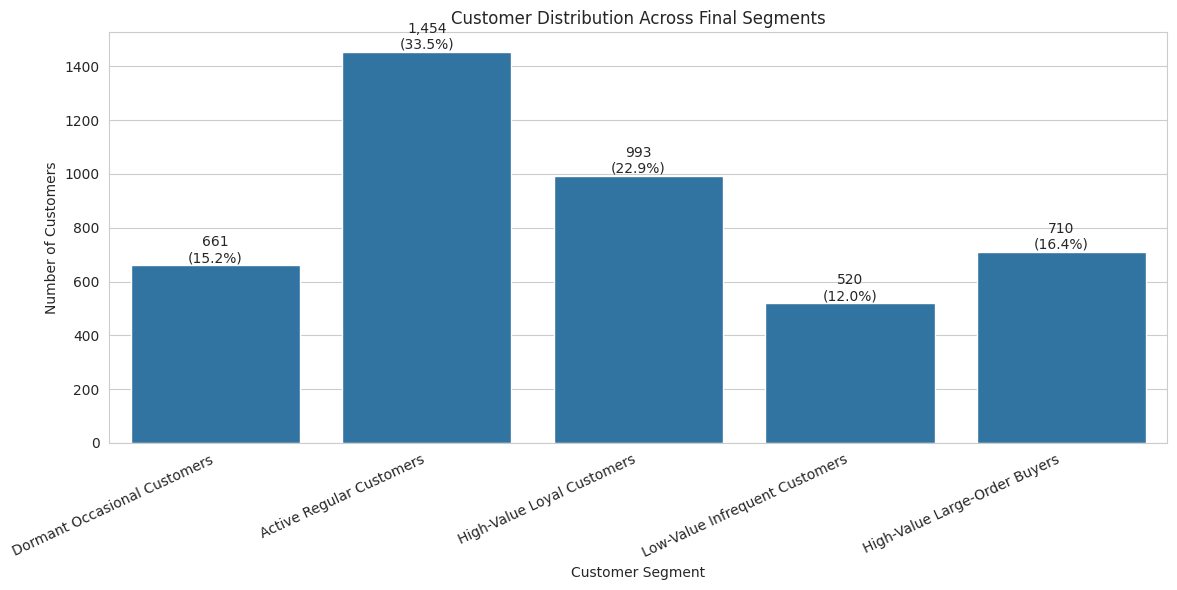

In [18]:
named_cluster_size = cluster_size.copy()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=named_cluster_size,
    x="Segment_Name",
    y="Customer_Count"
)

for index, row in named_cluster_size.iterrows():
    ax.text(
        index,
        row["Customer_Count"],
        (
            f'{row["Customer_Count"]:,}\n'
            f'({row["Customer_Percentage"]:.1f}%)'
        ),
        ha="center",
        va="bottom"
    )

plt.title("Customer Distribution Across Final Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    figures_dir / "final_named_segment_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  19: Calculate Monetary contribution by segment



MONETARY CONTRIBUTION BY SEGMENT


,Cluster,Segment_Name,Customer_Count,Total_Monetary_Value,Mean_Customer_Value,Median_Customer_Value,Customer_Percentage,Monetary_Value_Percentage
0,0,Dormant Occasional Customers,661,"239,320.1800",362.0600,311.5500,15.2400,2.6900
1,1,Active Regular Customers,1454,"904,586.0100",622.1400,550.5500,33.5200,10.1800
2,2,High-Value Loyal Customers,993,"6,192,568.2900","6,236.2200","2,888.5500",22.8900,69.6800
3,3,Low-Value Infrequent Customers,520,"85,841.8500",165.0800,128.5600,11.9900,0.9700
4,4,High-Value Large-Order Buyers,710,"1,464,892.5600","2,063.2300","1,160.7800",16.3700,16.4800


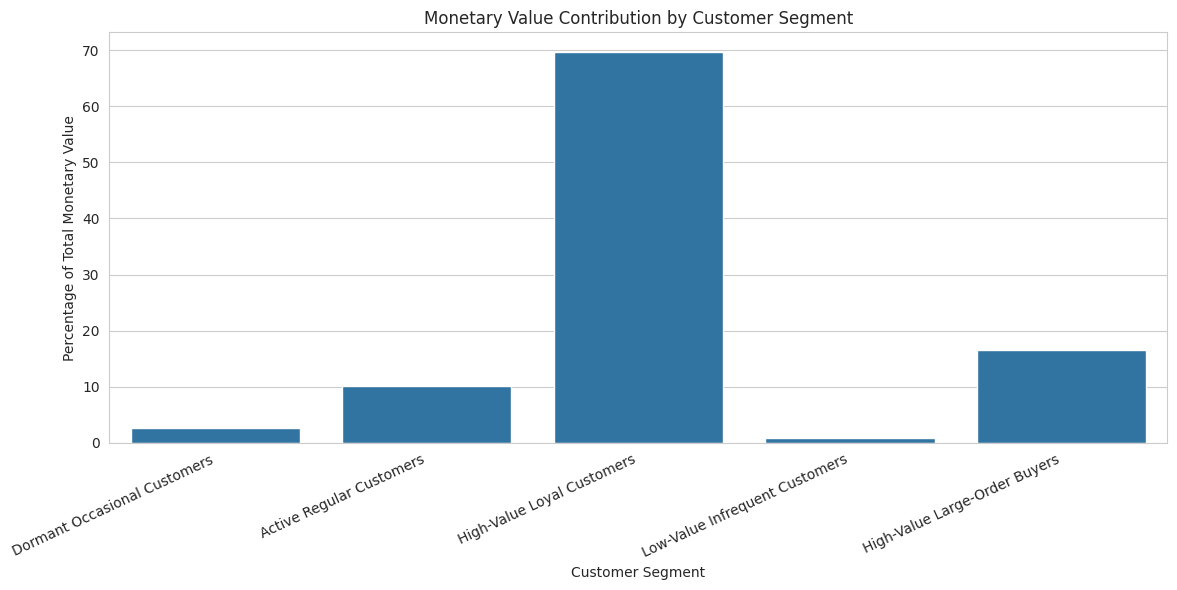

In [19]:
segment_value_summary = (
    raw_clustered
    .groupby(
        ["Cluster", "Segment_Name"]
    )
    .agg(
        Customer_Count=("CustomerID", "count"),
        Total_Monetary_Value=("Monetary", "sum"),
        Mean_Customer_Value=("Monetary", "mean"),
        Median_Customer_Value=("Monetary", "median")
    )
    .reset_index()
)

segment_value_summary["Customer_Percentage"] = (
    segment_value_summary["Customer_Count"]
    / len(raw_clustered)
    * 100
)

segment_value_summary["Monetary_Value_Percentage"] = (
    segment_value_summary["Total_Monetary_Value"]
    / segment_value_summary["Total_Monetary_Value"].sum()
    * 100
)

segment_value_summary = segment_value_summary.round(2)

print("=" * 80)
print("MONETARY CONTRIBUTION BY SEGMENT")
print("=" * 80)

display(segment_value_summary)

segment_value_summary.to_csv(
    tables_dir / "final_segment_monetary_contribution.csv",
    index=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_value_summary,
    x="Segment_Name",
    y="Monetary_Value_Percentage"
)

plt.title("Monetary Value Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Total Monetary Value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    figures_dir / "segment_monetary_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  20: Create segment feature quartiles



In [20]:
# SEGMENT FEATURE QUARTILES

segment_feature_quartiles = (
    raw_clustered
    .groupby(
        ["Cluster", "Segment_Name"]
    )[feature_columns]
    .quantile(
        [0.25, 0.50, 0.75]
    )
    .rename_axis(
        index=[
            "Cluster",
            "Segment_Name",
            "Quantile"
        ]
    )
    .reset_index()
)

segment_feature_quartiles["Quantile_Label"] = (
    segment_feature_quartiles["Quantile"]
    .map({
        0.25: "25th Percentile",
        0.50: "Median",
        0.75: "75th Percentile"
    })
)

segment_feature_quartiles_long = (
    segment_feature_quartiles
    .melt(
        id_vars=[
            "Cluster",
            "Segment_Name",
            "Quantile",
            "Quantile_Label"
        ],
        value_vars=feature_columns,
        var_name="Feature",
        value_name="Feature_Value"
    )
    .sort_values(
        [
            "Cluster",
            "Feature",
            "Quantile"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("SEGMENT FEATURE QUARTILES")
print("=" * 80)

display(
    segment_feature_quartiles_long.head(30)
)

segment_feature_quartiles.to_csv(
    tables_dir / "final_segment_feature_quartiles_wide.csv",
    index=False
)

segment_feature_quartiles_long.to_csv(
    tables_dir / "final_segment_feature_quartiles_long.csv",
    index=False
)


SEGMENT FEATURE QUARTILES


,Cluster,Segment_Name,Quantile,Quantile_Label,Feature,Feature_Value
0,0,Dormant Occasional Customers,0.2500,25th Percentile,AverageOrderValue,174.8000
1,0,Dormant Occasional Customers,0.5000,Median,AverageOrderValue,251.8000
2,0,Dormant Occasional Customers,0.7500,75th Percentile,AverageOrderValue,343.6200
3,0,Dormant Occasional Customers,0.2500,25th Percentile,BasketSize,88.0000
4,0,Dormant Occasional Customers,0.5000,Median,BasketSize,128.0000
5,0,Dormant Occasional Customers,0.7500,75th Percentile,BasketSize,188.0000
6,0,Dormant Occasional Customers,0.2500,25th Percentile,Frequency,1.0000
7,0,Dormant Occasional Customers,0.5000,Median,Frequency,1.0000
8,0,Dormant Occasional Customers,0.7500,75th Percentile,Frequency,2.0000
9,0,Dormant Occasional Customers,0.2500,25th Percentile,Monetary,207.7300


###  21: Create a compact Monetary quartile table



In [21]:
# A compact Monetary summary for easier interpretation.
segment_monetary_quartiles = (
    segment_feature_quartiles[
        [
            "Cluster",
            "Segment_Name",
            "Quantile_Label",
            "Monetary"
        ]
    ]
    .pivot(
        index=[
            "Cluster",
            "Segment_Name"
        ],
        columns="Quantile_Label",
        values="Monetary"
    )
    .reset_index()
)

display(segment_monetary_quartiles)

segment_monetary_quartiles.to_csv(
    tables_dir / "final_segment_monetary_quartiles.csv",
    index=False
)


Quantile_Label,Cluster,Segment_Name,25th Percentile,75th Percentile,Median
0,0,Dormant Occasional Customers,207.7300,429.6000,311.5500
1,1,Active Regular Customers,334.6550,820.1625,550.5500
2,2,High-Value Loyal Customers,"1,981.9200","4,921.0400","2,888.5500"
3,3,Low-Value Infrequent Customers,93.1925,195.2500,128.5650
4,4,High-Value Large-Order Buyers,768.5025,"1,793.5375","1,160.7850"


###  22: Assign a business objective and strategy

The final segments should lead to practical actions rather than only descriptive labels.


In [22]:
strategy_lookup = {
    "High-Value Loyal Customers": {
        "Primary_Objective": "Retention and loyalty",
        "Recommended_Strategy": (
            "Provide VIP rewards, early product access, personalised offers, "
            "priority service and referral incentives."
        ),
        "Recommended_Communication": (
            "Exclusive and relationship-focused communication."
        )
    },

    "High-Value Large-Order Buyers": {
        "Primary_Objective": "Protect and expand large orders",
        "Recommended_Strategy": (
            "Offer volume-based incentives, account support, replenishment "
            "reminders and large-order assistance."
        ),
        "Recommended_Communication": (
            "Focus on value, product availability and purchasing convenience."
        )
    },

    "Active Regular Customers": {
        "Primary_Objective": "Increase loyalty and customer value",
        "Recommended_Strategy": (
            "Use cross-selling, personalised recommendations, loyalty "
            "milestones, bundles and repeat-purchase incentives."
        ),
        "Recommended_Communication": (
            "Relevant recommendations and repeat-purchase encouragement."
        )
    },

    "Dormant Occasional Customers": {
        "Primary_Objective": "Customer reactivation",
        "Recommended_Strategy": (
            "Use targeted win-back campaigns, product reminders, personalised "
            "recommendations and limited-time return incentives."
        ),
        "Recommended_Communication": (
            "Re-engagement messages with a clear reason to return."
        )
    },

    "Low-Value Infrequent Customers": {
        "Primary_Objective": "Low-cost engagement and value development",
        "Recommended_Strategy": (
            "Use automated low-cost campaigns, entry-level offers, product "
            "education and response testing before increasing marketing spend."
        ),
        "Recommended_Communication": (
            "Simple, low-cost and incentive-led communication."
        )
    }
}

segment_definitions = []

for cluster, segment_name in sorted(segment_mapping.items()):
    strategy = strategy_lookup[segment_name]

    segment_definitions.append({
        "Cluster": cluster,
        "Segment_Name": segment_name,
        "Primary_Objective": strategy["Primary_Objective"],
        "Recommended_Strategy": strategy["Recommended_Strategy"],
        "Recommended_Communication": strategy[
            "Recommended_Communication"
        ]
    })

segment_definitions = pd.DataFrame(segment_definitions)

display(segment_definitions)

segment_definitions.to_csv(
    tables_dir / "final_segment_definitions_and_strategies.csv",
    index=False
)


,Cluster,Segment_Name,Primary_Objective,Recommended_Strategy,Recommended_Communication
0,0,Dormant Occasional Customers,Customer reactivation,"Use targeted win-back campaigns, product remin...",Re-engagement messages with a clear reason to ...
1,1,Active Regular Customers,Increase loyalty and customer value,"Use cross-selling, personalised recommendation...",Relevant recommendations and repeat-purchase e...
2,2,High-Value Loyal Customers,Retention and loyalty,"Provide VIP rewards, early product access, per...",Exclusive and relationship-focused communication.
3,3,Low-Value Infrequent Customers,Low-cost engagement and value development,"Use automated low-cost campaigns, entry-level ...","Simple, low-cost and incentive-led communication."
4,4,High-Value Large-Order Buyers,Protect and expand large orders,"Offer volume-based incentives, account support...","Focus on value, product availability and purch..."


## Phase 4: Stability testing

The final solution is tested against changes in random initialisation and customer sampling.


###  23: Test stability across random seeds

A stable solution should not change greatly because of a different centroid starting point.The K=5 model is fitted repeatedly using different random seeds and each result is compared with the final labels using Adjusted Rand Index.



In [23]:
seed_results = []

for seed in range(1, 31):
    seed_model = KMeans(
        n_clusters=FINAL_K,
        init="k-means++",
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=seed,
        algorithm="lloyd"
    )

    seed_labels = seed_model.fit_predict(X)

    seed_results.append({
        "Random_State": seed,
        "Adjusted_Rand_Index": adjusted_rand_score(
            final_labels,
            seed_labels
        ),
        "Inertia": seed_model.inertia_,
        "Iterations": seed_model.n_iter_
    })

seed_stability = pd.DataFrame(seed_results)

seed_stability_summary = pd.DataFrame({
    "Metric": [
        "Runs",
        "Mean ARI",
        "Median ARI",
        "Minimum ARI",
        "Maximum ARI",
        "ARI Standard Deviation",
        "Perfect Matches"
    ],
    "Value": [
        len(seed_stability),
        seed_stability["Adjusted_Rand_Index"].mean(),
        seed_stability["Adjusted_Rand_Index"].median(),
        seed_stability["Adjusted_Rand_Index"].min(),
        seed_stability["Adjusted_Rand_Index"].max(),
        seed_stability["Adjusted_Rand_Index"].std(),
        (seed_stability["Adjusted_Rand_Index"] == 1).sum()
    ]
})

print("=" * 80)
print("RANDOM-SEED STABILITY")
print("=" * 80)

display(seed_stability_summary)

seed_stability.to_csv(
    stability_dir / "final_k5_random_seed_runs.csv",
    index=False
)

seed_stability_summary.to_csv(
    stability_dir / "final_k5_random_seed_summary.csv",
    index=False
)


RANDOM-SEED STABILITY


,Metric,Value
0,Runs,30.0000
1,Mean ARI,0.9999
2,Median ARI,1.0000
3,Minimum ARI,0.9996
4,Maximum ARI,1.0000
5,ARI Standard Deviation,0.0002
6,Perfect Matches,23.0000


###  24: Test stability using repeated customer subsamples

The solution should also remain reasonably similar when part of the customer sample changes. Fifty models are fitted on random samples containing 80 percent of customers and compared with the final labels for those customers.


In [24]:
SUBSAMPLE_RUNS = 50
SUBSAMPLE_FRACTION = 0.80
SUBSAMPLE_RANDOM_STATE = 2026

random_generator = np.random.default_rng(
    SUBSAMPLE_RANDOM_STATE
)

sample_size = int(
    len(X) * SUBSAMPLE_FRACTION
)

subsample_results = []

for run_number in range(1, SUBSAMPLE_RUNS + 1):
    sampled_positions = random_generator.choice(
        len(X),
        size=sample_size,
        replace=False
    )

    sampled_positions = np.sort(sampled_positions)

    X_subsample = X.iloc[sampled_positions]
    baseline_sample_labels = final_labels[sampled_positions]

    subsample_model = KMeans(
        n_clusters=FINAL_K,
        init="k-means++",
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=SUBSAMPLE_RANDOM_STATE + run_number,
        algorithm="lloyd"
    )

    subsample_labels = subsample_model.fit_predict(
        X_subsample
    )

    subsample_results.append({
        "Run": run_number,
        "Sample_Size": sample_size,
        "Sample_Fraction": SUBSAMPLE_FRACTION,
        "Adjusted_Rand_Index": adjusted_rand_score(
            baseline_sample_labels,
            subsample_labels
        ),
        "Inertia": subsample_model.inertia_,
        "Iterations": subsample_model.n_iter_
    })

subsample_stability = pd.DataFrame(
    subsample_results
)

subsample_stability_summary = pd.DataFrame({
    "Metric": [
        "Runs",
        "Sample Fraction",
        "Sample Size",
        "Mean ARI",
        "Median ARI",
        "Minimum ARI",
        "Maximum ARI",
        "ARI Standard Deviation"
    ],
    "Value": [
        SUBSAMPLE_RUNS,
        SUBSAMPLE_FRACTION,
        sample_size,
        subsample_stability["Adjusted_Rand_Index"].mean(),
        subsample_stability["Adjusted_Rand_Index"].median(),
        subsample_stability["Adjusted_Rand_Index"].min(),
        subsample_stability["Adjusted_Rand_Index"].max(),
        subsample_stability["Adjusted_Rand_Index"].std()
    ]
})

print("=" * 80)
print("SUBSAMPLING STABILITY")
print("=" * 80)

display(subsample_stability_summary)

subsample_stability.to_csv(
    stability_dir / "final_k5_subsampling_runs.csv",
    index=False
)

subsample_stability_summary.to_csv(
    stability_dir / "final_k5_subsampling_summary.csv",
    index=False
)


SUBSAMPLING STABILITY


,Metric,Value
0,Runs,50.0000
1,Sample Fraction,0.8000
2,Sample Size,"3,470.0000"
3,Mean ARI,0.9541
4,Median ARI,0.9594
5,Minimum ARI,0.9011
6,Maximum ARI,0.9829
7,ARI Standard Deviation,0.0212


###  25: Plot the subsampling stability results


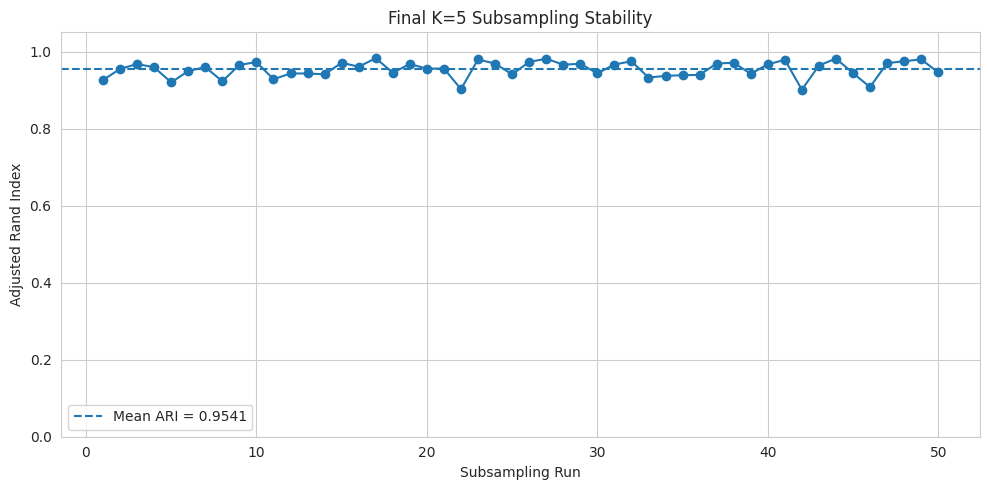

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    subsample_stability["Run"],
    subsample_stability["Adjusted_Rand_Index"],
    marker="o"
)

plt.axhline(
    subsample_stability["Adjusted_Rand_Index"].mean(),
    linestyle="--",
    label=(
        "Mean ARI = "
        f'{subsample_stability["Adjusted_Rand_Index"].mean():.4f}'
    )
)

plt.title("Final K=5 Subsampling Stability")
plt.xlabel("Subsampling Run")
plt.ylabel("Adjusted Rand Index")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "final_k5_subsampling_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Phase 5: Visualisation and dashboard preparation

PCA and profile charts are created, followed by the dashboard-ready customer data.


###  26: Create the PCA coordinates



In [26]:
pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

pca_coordinates = pca.fit_transform(X)

pca_clustered = pd.DataFrame({
    "CustomerID": processed_data["CustomerID"],
    "PC1": pca_coordinates[:, 0],
    "PC2": pca_coordinates[:, 1],
    "Cluster": final_labels,
    "Segment_Name": [
        segment_mapping[int(label)]
        for label in final_labels
    ]
})

pca_variance = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_Variance_Ratio": (
        pca.explained_variance_ratio_
    ),
    "Explained_Variance_Percentage": (
        pca.explained_variance_ratio_ * 100
    )
})

display(pca_variance)

pca_variance.to_csv(
    tables_dir / "final_pca_explained_variance.csv",
    index=False
)

pca_clustered.to_csv(
    datasets_dir / "final_pca_customer_segments.csv",
    index=False
)

# Save the fitted PCA object for reproducible visualisation.
joblib.dump(
    pca,
    models_dir / "final_pca_visualisation_model.joblib"
)

print(
    "PCA visualisation model saved successfully."
)


,Component,Explained_Variance_Ratio,Explained_Variance_Percentage
0,PC1,0.6156,61.5640
1,PC2,0.1980,19.8007


PCA visualisation model saved successfully.


###  27: Plot the customer segments using PCA




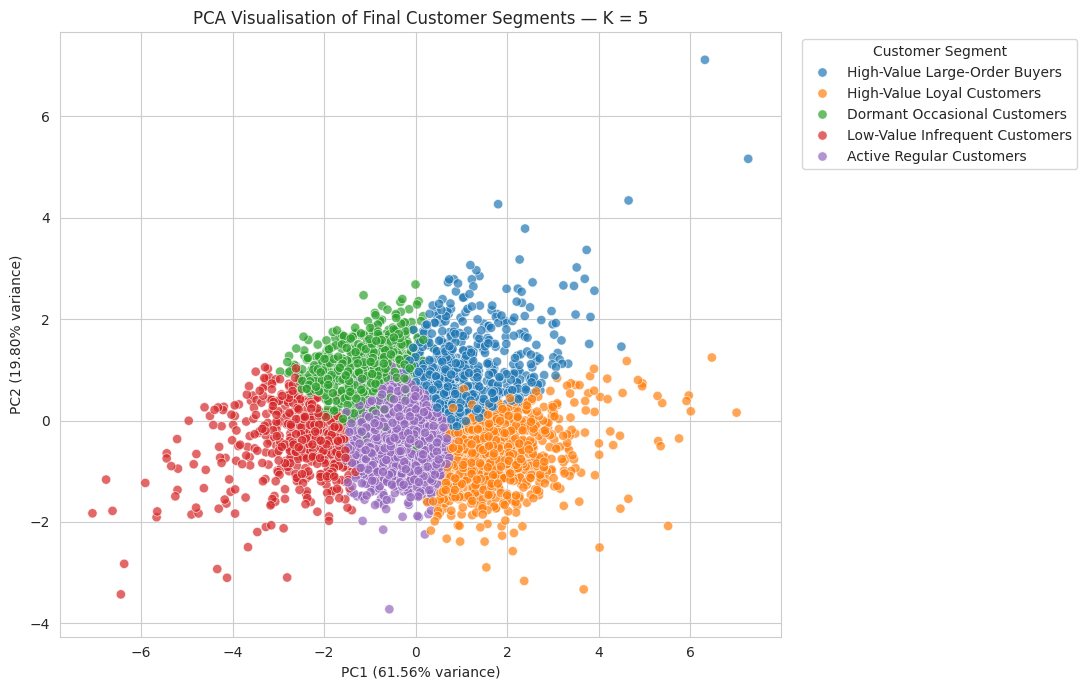

In [27]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_clustered,
    x="PC1",
    y="PC2",
    hue="Segment_Name",
    alpha=0.70,
    s=45
)

plt.title(
    "PCA Visualisation of Final Customer Segments — K = 5"
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
)

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    figures_dir / "final_k5_pca_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  28: Plot the named relative-profile heatmap



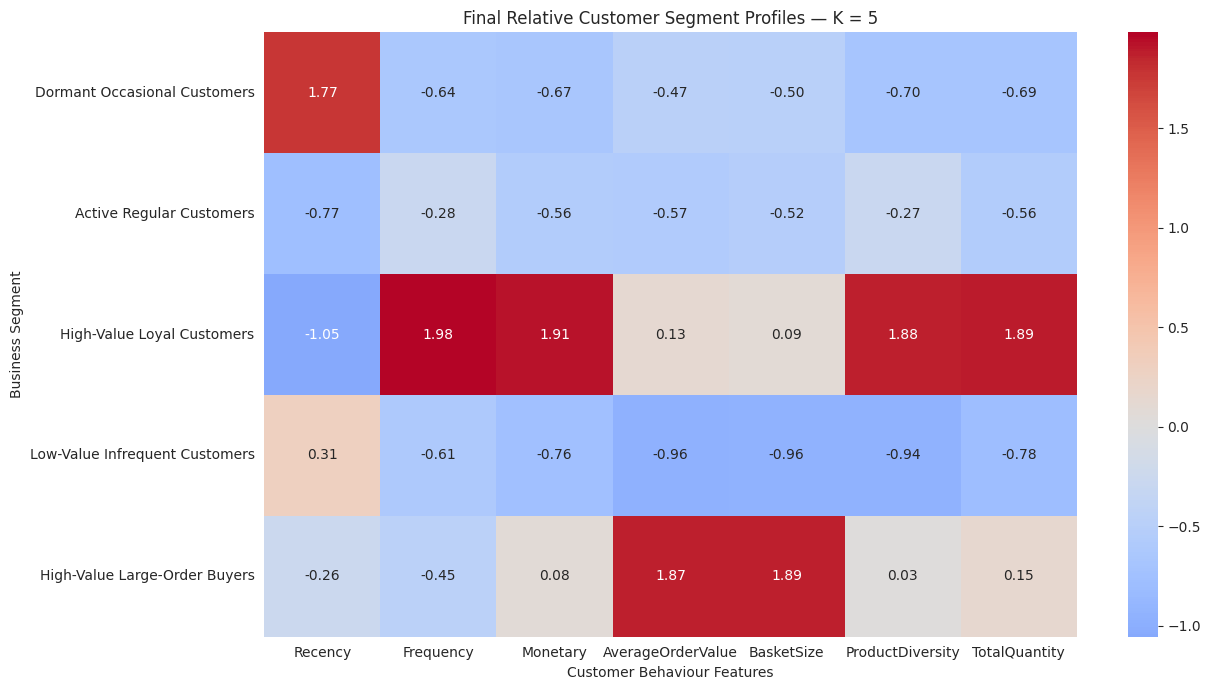

In [28]:
named_relative_profiles = relative_profiles.copy()

named_relative_profiles.index = [
    segment_mapping[int(cluster)]
    for cluster in named_relative_profiles.index
]

plt.figure(figsize=(13, 7))

sns.heatmap(
    named_relative_profiles,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Final Relative Customer Segment Profiles — K = 5")
plt.xlabel("Customer Behaviour Features")
plt.ylabel("Business Segment")
plt.tight_layout()

plt.savefig(
    figures_dir / "final_named_segment_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


###  29: Prepare the dashboard-ready customer dataset




In [29]:
dashboard_data = raw_clustered.merge(
    segment_definitions,
    on=["Cluster", "Segment_Name"],
    how="left",
    validate="many_to_one"
)

dashboard_data["Recency_Band"] = pd.cut(
    dashboard_data["Recency"],
    bins=[-np.inf, 30, 90, 180, np.inf],
    labels=[
        "0–30 days",
        "31–90 days",
        "91–180 days",
        "181+ days"
    ]
)

dashboard_data["Frequency_Band"] = pd.cut(
    dashboard_data["Frequency"],
    bins=[-np.inf, 1, 3, 6, np.inf],
    labels=[
        "1 purchase",
        "2–3 purchases",
        "4–6 purchases",
        "7+ purchases"
    ]
)

# Ranking before qcut prevents duplicate-boundary errors.\n# The field is therefore named Monetary_Rank_Quartile.
dashboard_data["Monetary_Rank_Quartile"] = pd.qcut(
    dashboard_data["Monetary"].rank(method="first"),
    q=4,
    labels=[
        "Q1 – Lowest",
        "Q2",
        "Q3",
        "Q4 – Highest"
    ]
)

dashboard_data["Silhouette_Quality"] = pd.cut(
    dashboard_data["Silhouette_Value"],
    bins=[-np.inf, 0, 0.25, 0.50, np.inf],
    labels=[
        "Ambiguous / Boundary Customer",
        "Low Separation",
        "Moderate Separation",
        "Strong Separation"
    ]
)

print("Dashboard-ready dataset shape:", dashboard_data.shape)
display(dashboard_data.head())


Dashboard-ready dataset shape: (4338, 18)


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity,Cluster,Silhouette_Value,Segment_Name,Primary_Objective,Recommended_Strategy,Recommended_Communication,Recency_Band,Frequency_Band,Monetary_Rank_Quartile,Silhouette_Quality
0,12346,326,1,"77,183.6000","77,183.6000","74,215.0000",1,74215,4,0.0884,High-Value Large-Order Buyers,Protect and expand large orders,"Offer volume-based incentives, account support...","Focus on value, product availability and purch...",181+ days,1 purchase,Q4 – Highest,Low Separation
1,12347,2,7,"4,310.0000",615.7100,351.1400,103,2458,2,0.3445,High-Value Loyal Customers,Retention and loyalty,"Provide VIP rewards, early product access, per...",Exclusive and relationship-focused communication.,0–30 days,7+ purchases,Q4 – Highest,Moderate Separation
2,12348,75,4,"1,797.2400",449.3100,585.2500,22,2341,4,0.1586,High-Value Large-Order Buyers,Protect and expand large orders,"Offer volume-based incentives, account support...","Focus on value, product availability and purch...",31–90 days,4–6 purchases,Q4 – Highest,Low Separation
3,12349,19,1,"1,757.5500","1,757.5500",631.0000,73,631,4,0.3175,High-Value Large-Order Buyers,Protect and expand large orders,"Offer volume-based incentives, account support...","Focus on value, product availability and purch...",0–30 days,1 purchase,Q4 – Highest,Moderate Separation
4,12350,310,1,334.4000,334.4000,197.0000,17,197,0,0.5066,Dormant Occasional Customers,Customer reactivation,"Use targeted win-back campaigns, product remin...",Re-engagement messages with a clear reason to ...,181+ days,1 purchase,Q2,Strong Separation


## Phase 6: Reproducibility, quality checks and export

The preprocessing artifacts, software details and all final model outputs are saved and checked.


###  30: Copy the fitted preprocessing artifact



In [30]:
preprocessing_candidates = [
    "/content/robust_scaler.joblib",
    "/content/preprocessing_pipeline.joblib",
    "/content/customer_preprocessing_pipeline.joblib"
]

copied_preprocessing_artifact = None

for candidate in preprocessing_candidates:
    if os.path.exists(candidate):
        destination = models_dir / Path(candidate).name
        shutil.copy(candidate, destination)
        copied_preprocessing_artifact = str(destination)
        break

if copied_preprocessing_artifact:
    print(
        "Preprocessing artifact copied:",
        copied_preprocessing_artifact
    )
else:
    print(
        "Warning: no fitted scaler or preprocessing pipeline was found. "
        "The saved K-Means model cannot be safely applied to future raw "
        "customers without the original fitted preprocessing object."
    )


###  31: Save the feature-engineering manifest



In [31]:
feature_engineering_manifest = {
    "customer_identifier": "CustomerID",
    "features": feature_columns,
    "feature_descriptions": {
        "Recency": "Days since the customer's most recent purchase.",
        "Frequency": "Number of unique completed invoices.",
        "Monetary": "Total customer monetary value.",
        "AverageOrderValue": "Monetary divided by Frequency.",
        "BasketSize": "TotalQuantity divided by Frequency.",
        "ProductDiversity": "Number of unique products purchased.",
        "TotalQuantity": "Total product quantity purchased."
    },
    "processed_input_required": True,
    "dashboard_fields": {
        "Monetary_Rank_Quartile": (
            "Quartile based on ranked Monetary values. "
            "Ranking is used to handle duplicate boundaries."
        ),
        "Silhouette_Quality": (
            "Descriptive dashboard band rather than "
            "a universal statistical threshold."
        )
    },
    "required_model_artifacts": [
        "final_kmeans_k5_model.joblib",
        "final_pca_visualisation_model.joblib",
        (
            "robust_scaler.joblib or the fitted "
            "preprocessing pipeline"
        )
    ],
    "important_note": (
        "Future customers must undergo the same cleaning, aggregation, "
        "log transformation and fitted scaling process before prediction."
    )
}

with open(
    reproducibility_dir / "feature_engineering_manifest.json",
    "w"
) as file:
    json.dump(
        feature_engineering_manifest,
        file,
        indent=4
    )


###  32: Save software versions and requirements




In [32]:
software_versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": metadata.version("matplotlib"),
    "seaborn": sns.__version__,
    "scikit-learn": sklearn.__version__,
    "joblib": joblib.__version__
}

with open(
    reproducibility_dir / "software_versions.json",
    "w"
) as file:
    json.dump(
        software_versions,
        file,
        indent=4
    )

requirements_lines = [
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"matplotlib=={metadata.version('matplotlib')}",
    f"seaborn=={sns.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"joblib=={joblib.__version__}"
]

with open(
    reproducibility_dir / "requirements.txt",
    "w"
) as file:
    file.write("\n".join(requirements_lines))

display(pd.DataFrame(
    software_versions.items(),
    columns=["Package", "Version"]
))


,Package,Version
0,python,3.12.13
1,numpy,2.0.2
2,pandas,2.2.2
3,matplotlib,3.10.0
4,seaborn,0.13.2
5,scikit-learn,1.6.1
6,joblib,1.5.3


###  33: Export the final datasets and cluster tables



In [33]:
processed_clustered.to_csv(
    datasets_dir / "final_processed_customer_segments.csv",
    index=False
)

raw_clustered.to_csv(
    datasets_dir / "final_original_scale_customer_segments.csv",
    index=False
)

dashboard_data.to_csv(
    datasets_dir / "dashboard_ready_customer_segments.csv",
    index=False
)

cluster_size.to_csv(
    tables_dir / "final_cluster_size_with_names.csv",
    index=False
)

silhouette_summary.to_csv(
    tables_dir / "final_cluster_silhouette_summary_with_names.csv",
    index=False
)

cluster_profile_mean_named.to_csv(
    tables_dir / "final_cluster_profiles_mean_with_names.csv",
    index=False
)

cluster_profile_median_named.to_csv(
    tables_dir / "final_cluster_profiles_median_with_names.csv",
    index=False
)

final_centroids = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=feature_columns
)

final_centroids.insert(
    0,
    "Cluster",
    range(FINAL_K)
)

final_centroids["Segment_Name"] = (
    final_centroids["Cluster"].map(segment_mapping)
)

final_centroids.to_csv(
    tables_dir / "final_k5_scaled_centroids.csv",
    index=False
)

print("Final datasets and tables exported successfully.")


Final datasets and tables exported successfully.


###  34: Run the final assertion checks




In [34]:
# FINAL OUTPUT QUALITY CHECKS

# Dataset and identifier checks
assert len(raw_clustered) == len(processed_clustered)
assert len(raw_clustered) == len(dashboard_data)

assert raw_clustered["CustomerID"].is_unique
assert processed_clustered["CustomerID"].is_unique
assert dashboard_data["CustomerID"].is_unique

# Cluster and segment checks
assert raw_clustered["Cluster"].nunique() == FINAL_K
assert processed_clustered["Cluster"].nunique() == FINAL_K
assert raw_clustered["Segment_Name"].nunique() == FINAL_K

assert raw_clustered["Segment_Name"].notna().all()
assert processed_clustered["Segment_Name"].notna().all()
assert dashboard_data["Segment_Name"].notna().all()

# Size and percentage checks
assert cluster_size["Customer_Count"].sum() == len(
    raw_clustered
)

assert np.isclose(
    cluster_size["Customer_Percentage"].sum(),
    100,
    atol=0.10
)

assert np.isclose(
    segment_value_summary[
        "Monetary_Value_Percentage"
    ].sum(),
    100,
    atol=0.10
)

# Model reproducibility checks
assert np.array_equal(
    final_labels,
    reloaded_labels
)

assert saved_model_path.exists()

pca_model_path = (
    models_dir / "final_pca_visualisation_model.joblib"
)

assert pca_model_path.exists()

# Required output files
required_output_files = [
    datasets_dir / "final_processed_customer_segments.csv",
    datasets_dir / "final_original_scale_customer_segments.csv",
    datasets_dir / "dashboard_ready_customer_segments.csv",
    tables_dir / "final_cluster_profiles_mean_with_names.csv",
    tables_dir / "final_cluster_profiles_median_with_names.csv",
    tables_dir / "final_segment_monetary_contribution.csv",
    tables_dir / "final_segment_feature_quartiles_long.csv",
    tables_dir / "final_cluster_silhouette_summary_with_names.csv"
]

missing_output_files = [
    str(path)
    for path in required_output_files
    if not path.exists()
]

if missing_output_files:
    raise FileNotFoundError(
        "Missing expected output files:\n"
        + "\n".join(missing_output_files)
    )


###  35: Creatimng the quality-control summary




In [35]:
quality_control_summary = pd.DataFrame({
    "Quality_Check": [
        "Customer rows aligned",
        "Customer IDs unique",
        "Five clusters present",
        "Five segment names present",
        "No missing segment names",
        "Cluster percentages sum to 100",
        "Monetary shares sum to 100",
        "Reloaded model reproduces labels",
        "PCA model saved",
        "Required output files created"
    ],
    "Passed": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True
    ]
})

display(quality_control_summary)

quality_control_summary.to_csv(
    tables_dir / "final_output_quality_checks.csv",
    index=False
)

print("All final output quality checks passed.")


,Quality_Check,Passed
0,Customer rows aligned,True
1,Customer IDs unique,True
2,Five clusters present,True
3,Five segment names present,True
4,No missing segment names,True
5,Cluster percentages sum to 100,True
6,Monetary shares sum to 100,True
7,Reloaded model reproduces labels,True
8,PCA model saved,True
9,Required output files created,True


All final output quality checks passed.


### Block 36: Save the final model summary as JSON



In [36]:
final_model_summary = {
    "algorithm": "K-Means",
    "selected_k": FINAL_K,
    "scope": (
        "Final K=5 operational model using all seven selected customer "
        "features. Optimal-K selection was performed in a separate notebook."
    ),
    "selection_basis": (
        "K=5 was selected as the operational segmentation because it "
        "provided five actionable customer profiles while retaining "
        "acceptable internal validation and strong stability."
    ),
    "statistical_benchmark": (
        "K=2 achieved the strongest internal validation in the separate "
        "K=2 to K=10 evaluation notebook."
    ),
    "features": feature_columns,
    "random_state": RANDOM_STATE,
    "n_init": N_INIT,
    "max_iter": MAX_ITER,
    "customers": int(len(X)),
    "inertia": float(final_inertia),
    "silhouette_score": float(final_silhouette),
    "davies_bouldin_index": float(final_dbi),
    "calinski_harabasz_index": float(final_ch),
    "ambiguous_boundary_customers": overall_negative_count,
    "ambiguous_boundary_percentage": float(
        overall_negative_percentage
    ),
    "mean_random_seed_ari": float(
        seed_stability["Adjusted_Rand_Index"].mean()
    ),
    "minimum_random_seed_ari": float(
        seed_stability["Adjusted_Rand_Index"].min()
    ),
    "mean_subsampling_ari": float(
        subsample_stability["Adjusted_Rand_Index"].mean()
    ),
    "minimum_subsampling_ari": float(
        subsample_stability["Adjusted_Rand_Index"].min()
    ),
    "preprocessing_artifact": copied_preprocessing_artifact,
    "pca_visualisation_artifact": str(
        models_dir / "final_pca_visualisation_model.joblib"
    ),
    "dashboard_monetary_band_field": (
        "Monetary_Rank_Quartile"
    ),
    "saved_model_verified": True,
    "final_quality_checks_passed": True,
    "segment_mapping": {
        str(cluster): name
        for cluster, name in segment_mapping.items()
    }
}

with open(
    tables_dir / "final_kmeans_model_k5__summary.json",
    "w"
) as file:
    json.dump(
        final_model_summary,
        file,
        indent=4
    )


###  37: Create a short supervisor summary


In [37]:
supervisor_summary = f'''
FINAL K-MEANS K=5 SUMMARY

The final model used all seven processed customer features:
{", ".join(feature_columns)}.

K=5 was selected as the operational solution in the preceding evaluation
stage. The statistical benchmark was K=2, but K=5 was retained because it
provided five actionable customer profiles.

Final validation:
- Silhouette Score: {final_silhouette:.4f}
- Davies-Bouldin Index: {final_dbi:.4f}
- Calinski-Harabasz Index: {final_ch:.4f}
- Mean random-seed ARI: {seed_stability["Adjusted_Rand_Index"].mean():.4f}
- Mean 80% subsampling ARI: {subsample_stability["Adjusted_Rand_Index"].mean():.4f}
- Ambiguous/boundary customers: {overall_negative_count}
  ({overall_negative_percentage:.2f}%)

The solution should be described as having moderate internal separation,
strong stability, practical cluster sizes and useful business profiles.
It should not be described as perfectly separated or as having supervised
classification accuracy.
'''.strip()

with open(
    results_dir / "supervisor_summary.txt",
    "w"
) as file:
    file.write(supervisor_summary)


###  38: Create the final ZIP archive



In [38]:
zip_path = shutil.make_archive(
    base_name="/content/Final_KMeans_K5_Updated_Results",
    format="zip",
    root_dir=results_dir
)

print("=" * 80)
print("FINAL K-MEANS NOTEBOOK COMPLETED")
print("=" * 80)

print("Main output folder:", results_dir)
print("ZIP file:", zip_path)

print("\nImportant outputs:")
print("1. final_kmeans_k5_model.joblib")
print("2. final_original_scale_customer_segments.csv")
print("3. dashboard_ready_customer_segments.csv")
print("4. final_cluster_profiles_mean_with_names.csv")
print("5. final_segment_monetary_contribution.csv")
print("6. final_cluster_silhouette_summary_with_names.csv")
print("7. final_segment_definitions_and_strategies.csv")
print("8. final_kmeans_model_summary.json")
print("9. final_segment_feature_quartiles_long.csv")
print("10. final_output_quality_checks.csv")
print("11. final_pca_visualisation_model.joblib")
print("12. supervisor_summary.txt")


FINAL K-MEANS NOTEBOOK COMPLETED
Main output folder: /content/Final_KMeans_K5_Updated_Results
ZIP file: /content/Final_KMeans_K5_Updated_Results.zip

Important outputs:
1. final_kmeans_k5_model.joblib
2. final_original_scale_customer_segments.csv
3. dashboard_ready_customer_segments.csv
4. final_cluster_profiles_mean_with_names.csv
5. final_segment_monetary_contribution.csv
6. final_cluster_silhouette_summary_with_names.csv
7. final_segment_definitions_and_strategies.csv
8. final_kmeans_model_summary.json
9. final_segment_feature_quartiles_long.csv
10. final_output_quality_checks.csv
11. final_pca_visualisation_model.joblib
12. supervisor_summary.txt
